# 2002 AA29

## Initialize

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from astropy.time import Time
from astroquery.jplhorizons import Horizons

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

In [7]:
AU_TO_KM = 1.495978707e8
EARTH_RADIUS_KM = 6371.0
DAYS_PER_JULIAN_YEAR = 365.25
KM3S2_TO_AU3D2 = (86400**2) / (AU_TO_KM**3)

# primary body (sun)
NAME_PRIMARY = 'Sun'
MU_PRIMARY = 1.32712440018e11
COLOR_PRIMARY = 'darkorange'

# secondary body (earth)
NAME_SECONDARY = 'Earth'
MU_SECONDARY = 3.986004418e5
COLOR_SECONDARY = 'dodgerblue'

MU = MU_SECONDARY / (MU_PRIMARY + MU_SECONDARY)

# particle (2002 AA29)
NAME_PARTICLE = '99942 Apophis'
COLOR_PARTICLE = 'indianred'

EPOCH_START_JD = 2462239.5

# scale factor
K = 2 * np.pi / DAYS_PER_JULIAN_YEAR


In [8]:
def get_rotation_coords(vec_particle, vec_secondary):
    theta = np.arctan2(vec_secondary['y'], vec_secondary['x'])
    omega = (vec_secondary['x'] * vec_secondary['vy'] - vec_secondary['y'] * vec_secondary['vx']) / (vec_secondary['x']**2 + vec_secondary['y']**2)

    dx = vec_particle['x'] - vec_secondary['x']
    dy = vec_particle['y'] - vec_secondary['y']
    dz = vec_particle['z'] - vec_secondary['z']
    
    dvx = vec_particle['vx'] - vec_secondary['vx']
    dvy = vec_particle['vy'] - vec_secondary['vy']
    dvz = vec_particle['vz'] - vec_secondary['vz']
    
    x_rot = dx * np.cos(theta) + dy * np.sin(theta)
    y_rot = -dx * np.sin(theta) + dy * np.cos(theta)
    z_rot = dz
    
    vx_rot = (dvx * np.cos(theta) + dvy * np.sin(theta)) + (omega * y_rot)
    vy_rot = (-dvx * np.sin(theta) + dvy * np.cos(theta)) - (omega * x_rot)
    vz_rot = dvz
    
    return pd.DataFrame({
        'x': x_rot, 'y': y_rot, 'z': z_rot,
        'vx': vx_rot, 'vy': vy_rot, 'vz': vz_rot
    })

def get_jacobi_constant(vec_particle, vec_secondary):
    x, y, z = vec_particle['x'], vec_particle['y'], vec_particle['z']
    vx, vy, vz = vec_particle['vx'], vec_particle['vy'], vec_particle['vz']
    x_s, y_s, z_s = vec_secondary['x'], vec_secondary['y'], vec_secondary['z']
    
    r1 = np.sqrt(x**2 + y**2 + z**2)
    r2 = np.sqrt((x - x_s)**2 + (y - y_s)**2 + (z - z_s)**2)
    
    potential_term = (1 - MU) / r1 + MU / r2
    centrifugal_term = (x * vy - y * vx) / K
    velocity_term = (vx**2 + vy**2 + vz**2) / K**2

    cj = 2 * potential_term + 2 * centrifugal_term - velocity_term
    
    return cj

def get_iso_date(t_days):
    jd = np.array(t_days) + EPOCH_START_JD
    t = Time(jd, format='jd').iso[:10]
    return t

In [9]:
# Mercury6 data
col = ['time', 'long', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'a', 'e', 'i']

# Apophis Encounter: 2462239.5 to 2462241.5
vec_apophis = pd.read_csv('Apophis/APOPHIS.aei', sep='\s+', skiprows=4, names=col)
vec_earth = pd.read_csv('Apophis/EARTH.aei', sep='\s+', skiprows=4, names=col)

vec_apophis_rot = get_rotation_coords(vec_apophis, vec_earth)
x_rot, y_rot, z_rot = vec_apophis_rot['x'], vec_apophis_rot['y'], vec_apophis_rot['z']

In [10]:
# Horizons Data
duration_days = 2
stop_jd = EPOCH_START_JD + duration_days

start_iso = Time(EPOCH_START_JD, format='jd').to_value('iso', subfmt='date')
stop_iso = Time(stop_jd, format='jd').to_value('iso', subfmt='date')

epochs = {
    'start': start_iso,
    'stop': stop_iso,
    'step': '1d'
}

obj_apophis_hor = Horizons(id='Apophis', location='@sun', epochs=epochs)
vec_apophis_hor = obj_apophis_hor.vectors()

obj_earth_hor = Horizons(id=3, location='@sun', epochs=epochs)
vec_earth_hor = obj_earth_hor.vectors()

vec_apophis_rot_hor = get_rotation_coords(vec_apophis_hor, vec_earth_hor)
x_rot_hor, y_rot_hor, z_rot_hor = vec_apophis_rot_hor['x'], vec_apophis_rot_hor['y'], vec_apophis_rot_hor['z']

/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


## Apophis Encounter

/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


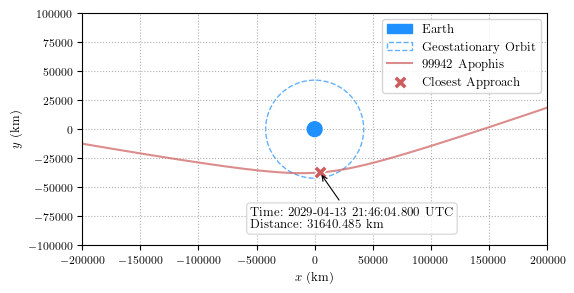

In [11]:
x_rot_km, y_rot_km, z_rot_km = x_rot * AU_TO_KM, y_rot * AU_TO_KM, z_rot * AU_TO_KM

# Closest Approach
dist = np.sqrt(x_rot_km**2 + y_rot_km**2 + z_rot_km**2)
min_idx = dist.idxmin()
closest_x, closest_y, closest_z = x_rot_km[min_idx], y_rot_km[min_idx], z_rot_km[min_idx]

min_dist = dist[min_idx] - EARTH_RADIUS_KM
min_time = vec_apophis['time'][min_idx] + EPOCH_START_JD
min_time_iso = Time(min_time, format='jd').iso

# Rotational Coordinates Plotting
fig, ax = plt.subplots(figsize=(6, 4))

earth = plt.Circle((0, 0), EARTH_RADIUS_KM, label=NAME_SECONDARY, color=COLOR_SECONDARY, zorder=2)
ax.add_patch(earth)

geo = plt.Circle((0, 0), 42164, label='Geostationary Orbit', color=COLOR_SECONDARY, fill=False, linestyle='--', alpha=0.7, zorder=1)
ax.add_patch(geo)

ax.plot(x_rot_km, y_rot_km, label=NAME_PARTICLE, color=COLOR_PARTICLE, alpha=0.7)
ax.scatter(closest_x, closest_y, label='Closest Approach', color=COLOR_PARTICLE, marker='X', edgecolors='white', s=100, zorder=3)

label_text = f"Time: {min_time_iso} UTC\nDistance: {min_dist:.3f} km"
ax.annotate(label_text,
            xy=(closest_x, closest_y), 
            xytext=(-50, -40),
            textcoords='offset points', 
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3', edgecolor='lightgray'),
            fontsize=9, zorder=5)

ax.set_xlim(-200000, 200000)
ax.set_ylim(-100000, 100000)
ax.set_aspect('equal')
ax.set_xlabel('$x$ (km)')
ax.set_ylabel('$y$ (km)')
ax.legend()
ax.grid(True, linestyle=':')

fig.savefig('apophis_enc.pdf', format='pdf', bbox_inches='tight')
plt.show()

/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 2001 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


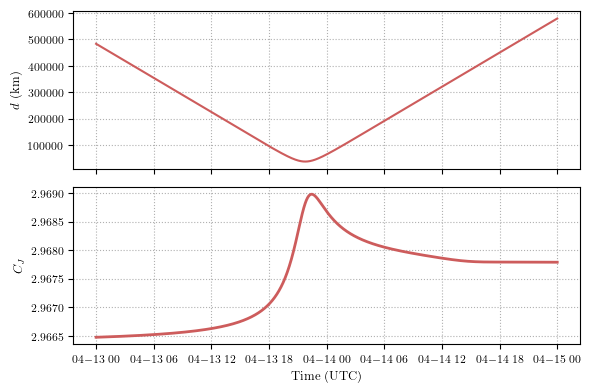

In [12]:
cj_values = get_jacobi_constant(vec_apophis, vec_earth)

time_jd = vec_apophis['time'] + EPOCH_START_JD
time_dt = Time(time_jd, format='jd').to_datetime()

dt_dist = time_dt[min_idx]

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

# Distance
ax1.plot(time_dt, dist, color=COLOR_PARTICLE, lw=1.5)
ax1.set_ylabel('$d$ (km)')
ax1.grid(True, linestyle=':')

# Jacobi constant
ax2.plot(time_dt, cj_values, color=COLOR_PARTICLE, lw=2)

ax2.set_xlabel('Time (UTC)')
ax2.set_ylabel('$C_J$')

ax2.grid(True, linestyle=':')
plt.tight_layout()

fig.savefig('apophis_jacobi.pdf', format='pdf', bbox_inches='tight')
plt.show()

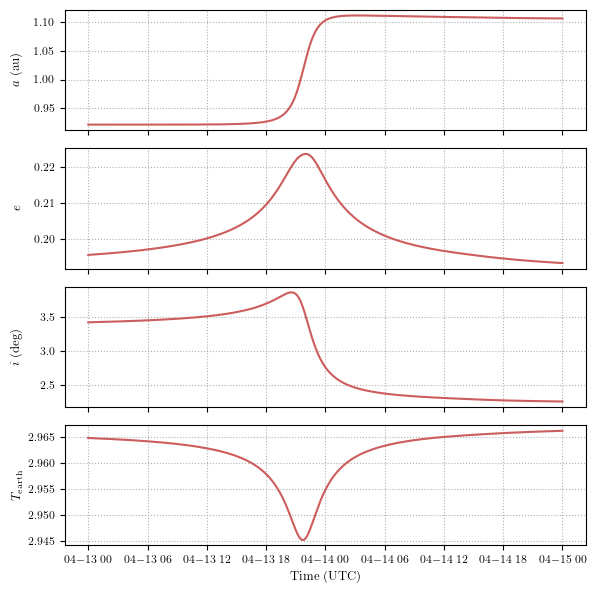

In [13]:
T_e = vec_earth['a'] / vec_apophis['a'] + 2 * np.sqrt((vec_apophis['a'] / vec_earth['a']) * (1 - vec_apophis['e']**2)) * np.cos(np.deg2rad(vec_apophis['i']))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(6, 6), sharex=True)

ax1.plot(time_dt, vec_apophis['a'], color=COLOR_PARTICLE)
ax1.set_ylabel('$a$ (au)')
ax1.grid(True, linestyle=':')

ax2.plot(time_dt, vec_apophis['e'], color=COLOR_PARTICLE)
ax2.set_ylabel('$e$')
ax2.grid(True, linestyle=':')

ax3.plot(time_dt, vec_apophis['i'], color=COLOR_PARTICLE)
ax3.set_ylabel('$i$ (deg)')
ax3.grid(True, linestyle=':')

ax4.plot(time_dt, T_e, color=COLOR_PARTICLE)
ax4.set_xlabel('Time (UTC)')
ax4.set_ylabel('$T_\mathrm{earth}$')
ax4.grid(True, linestyle=':')

fig.align_ylabels()
plt.tight_layout()

fig.savefig('apophis_tisserand.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Horizons Data Comparison

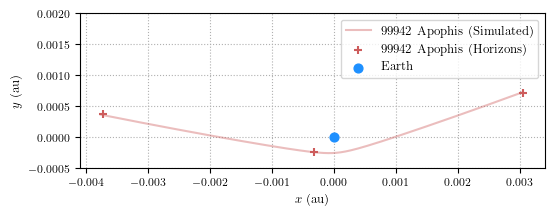

In [14]:
mask_hor = (vec_apophis['time'] >= 0) & (vec_apophis['time'] <= 2)

# Horizons Rotational Coordinates Plotting
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(x_rot[mask_hor], y_rot[mask_hor], label=f"{NAME_PARTICLE} (Simulated)", color=COLOR_PARTICLE, alpha=0.4, zorder=2)
ax.scatter(x_rot_hor, y_rot_hor, label=f"{NAME_PARTICLE} (Horizons)", color=COLOR_PARTICLE, marker='+', s=40, zorder=3)

ax.scatter(0, 0, label=NAME_SECONDARY, color=COLOR_SECONDARY, s=40, zorder=3)

ax.set_aspect('equal')
ax.set_xlabel('$x$ (au)')
ax.set_ylabel('$y$ (au)')
ax.set_ylim(-0.0005, 0.002)
ax.legend()
ax.grid(True, linestyle=':')

fig.savefig('apophis_hor.pdf', format='pdf', bbox_inches='tight')
plt.show()